# 01 — FastSurfer vs T1Prep concordance

On DLBS sub-1003 (all three waves, ages 54/58/63), compute and plot:

- Tissue volumes per tool per wave (GM/WM; FastSurfer cortex-only vs T1Prep whole-GM is not apples-to-apples by definition, so we report both conventions and note the gap).
- DK cortical ROI volume correlation (FastSurfer aseg+DKT vs T1Prep thickness covariation).
- Longitudinal trajectories per ROI.

Inputs land from:
- `scripts/extract_fastsurfer_features.py` → `results/fastsurfer_features.parquet`
- `scripts/extract_t1prep_features.py`     → `results/t1prep_features.parquet`

sub-1003 participant metadata: male, MMSE 28/30/28, education 15 yr, handedness 4, height 68.5", weight 213/220 lb, BMI 31.9/33.4.


In [1]:
from __future__ import annotations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd()  # expected: experiments/dlbs_morphometry_benchmark/notebooks
RESULTS = HERE.parents[0] / 'results'
fs  = pd.read_parquet(RESULTS / 'fastsurfer_features.parquet')
t1p = pd.read_parquet(RESULTS / 't1prep_features.parquet')
print('fs rows:', len(fs), 'subjects:', fs['subject'].nunique())
print('t1prep rows:', len(t1p), 'subjects:', t1p['subject'].nunique())
SUBJECT = 'sub-1003'
WAVES = ['ses-wave1', 'ses-wave2', 'ses-wave3']
AGES = {'ses-wave1': 54, 'ses-wave2': 58, 'ses-wave3': 63}

fs rows: 495 subjects: 1
t1prep rows: 384 subjects: 1


## Total tissue volumes per wave

In [2]:
# FastSurfer: GM = ctx only (Cerebral Cortex), WM = Cerebral WM.
fs_aseg = fs[fs['tool'] == 'aseg.VINN'].set_index(['session', 'region'])['volume_mm3']
rows = []
for w in WAVES:
    rows.append({
        'session': w, 'tool': 'FastSurfer (aseg)',
        'GM_cortex_mm3': fs_aseg.loc[w, 'Left-Cerebral-Cortex'] + fs_aseg.loc[w, 'Right-Cerebral-Cortex'],
        'WM_mm3': fs_aseg.loc[w, 'Left-Cerebral-White-Matter'] + fs_aseg.loc[w, 'Right-Cerebral-White-Matter'],
    })

# T1Prep: GM / WM / CSF / TIV from p0 tissue-label thresholds.
t1_tis = t1p[t1p['tool'] == 't1prep_tissue'].set_index(['session', 'region'])['volume_mm3']
for w in WAVES:
    rows.append({
        'session': w, 'tool': 'T1Prep (p0)',
        'GM_all_mm3': t1_tis.loc[w, 'GM'],
        'WM_mm3': t1_tis.loc[w, 'WM'],
        'CSF_mm3': t1_tis.loc[w, 'CSF'],
        'TIV_mm3': t1_tis.loc[w, 'TIV'],
    })
totals = pd.DataFrame(rows)
totals

,session,tool,GM_cortex_mm3,WM_mm3,GM_all_mm3,CSF_mm3,TIV_mm3
0,ses-wave1,FastSurfer (aseg),452233.470,534416.562,NaN,NaN,NaN
1,ses-wave2,FastSurfer (aseg),438860.015,523278.078,NaN,NaN,NaN
2,ses-wave3,FastSurfer (aseg),434351.627,507295.567,NaN,NaN,NaN
3,ses-wave1,T1Prep (p0),NaN,605503.000,693079.0,281526.0,1580108.0
4,ses-wave2,T1Prep (p0),NaN,588155.000,684156.0,319478.0,1591789.0
5,ses-wave3,T1Prep (p0),NaN,561009.000,672502.0,343625.0,1577136.0


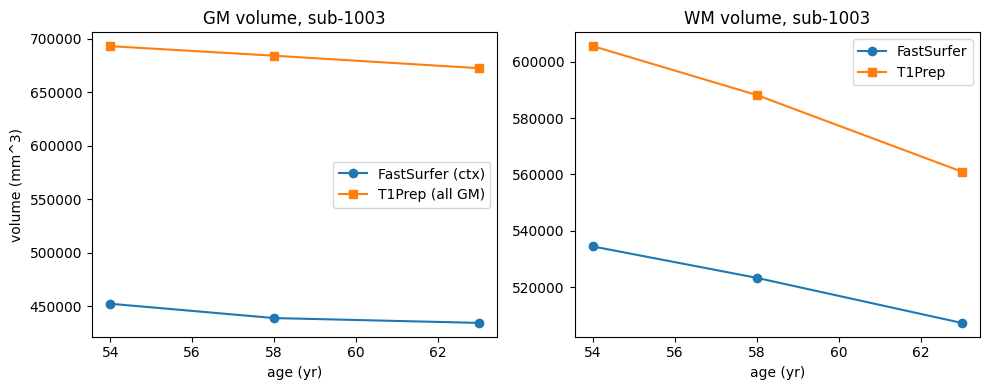

In [3]:
# Longitudinal plot of GM/WM by tool
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
ages = [AGES[w] for w in WAVES]
fs_gm = [fs_aseg.loc[w, 'Left-Cerebral-Cortex'] + fs_aseg.loc[w, 'Right-Cerebral-Cortex'] for w in WAVES]
fs_wm = [fs_aseg.loc[w, 'Left-Cerebral-White-Matter'] + fs_aseg.loc[w, 'Right-Cerebral-White-Matter'] for w in WAVES]
t1_gm = [t1_tis.loc[w, 'GM'] for w in WAVES]
t1_wm = [t1_tis.loc[w, 'WM'] for w in WAVES]

axes[0].plot(ages, fs_gm, 'o-', label='FastSurfer (ctx)')
axes[0].plot(ages, t1_gm, 's-', label='T1Prep (all GM)')
axes[0].set_title('GM volume, sub-1003')
axes[0].set_xlabel('age (yr)'); axes[0].set_ylabel('volume (mm^3)')
axes[0].legend()

axes[1].plot(ages, fs_wm, 'o-', label='FastSurfer')
axes[1].plot(ages, t1_wm, 's-', label='T1Prep')
axes[1].set_title('WM volume, sub-1003')
axes[1].set_xlabel('age (yr)')
axes[1].legend()
fig.tight_layout()
fig.savefig(str(RESULTS / 'sub-1003_longitudinal_volumes.png'), dpi=110)
plt.show()

## DK ROI volume correlation — FastSurfer aseg+DKT vs T1Prep thickness

FastSurfer DK cortex ROIs are reported as volume in `aseg+DKT.VINN.stats`. T1Prep emits
per-vertex thickness, which we aggregate to per-ROI mean thickness. These are different units,
so we scatter them rather than treating them as the same quantity.

shared DK ROIs x 3 waves: 162
per-wave Pearson r of (fs_vol, t1_thick) across ROIs:
  ses-wave1: r = +0.032  (n=54 ROIs)
  ses-wave2: r = -0.040  (n=62 ROIs)
  ses-wave3: r = -0.027  (n=46 ROIs)


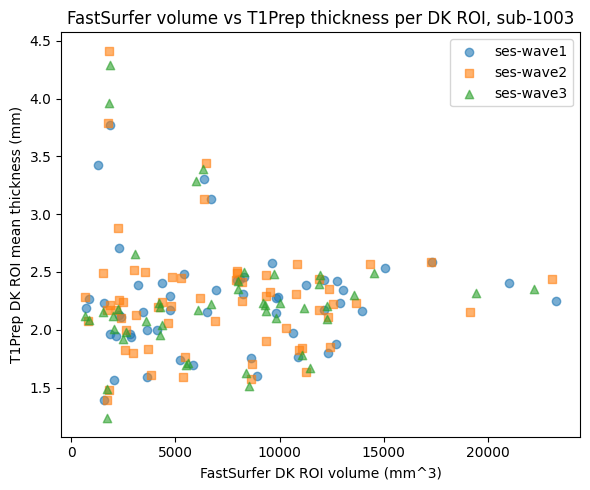

In [4]:
fs_dkt = fs[fs['tool'] == 'aseg+DKT.VINN']
t1_thick = t1p[t1p['tool'] == 't1prep_thickness']

rows = []
for w in WAVES:
    fs_w = fs_dkt[fs_dkt['session'] == w].set_index('region')['volume_mm3']
    t1_w = t1_thick[t1_thick['session'] == w].set_index('region')['thickness_mm']
    common = sorted(set(fs_w.index) & set(t1_w.index) & {r for r in fs_w.index if r.startswith('ctx-')})
    for r in common:
        rows.append({
            'session': w, 'region': r,
            'fs_vol_mm3': fs_w[r], 't1_thick_mm': t1_w[r],
        })
dk = pd.DataFrame(rows)
print('shared DK ROIs x 3 waves:', len(dk))
print('per-wave Pearson r of (fs_vol, t1_thick) across ROIs:')
for w in WAVES:
    sub = dk[dk['session'] == w]
    if len(sub):
        r = np.corrcoef(sub['fs_vol_mm3'], sub['t1_thick_mm'])[0, 1]
        print(f'  {w}: r = {r:+.3f}  (n={len(sub)} ROIs)')

fig, ax = plt.subplots(figsize=(6, 5))
for w, m in zip(WAVES, ['o', 's', '^']):
    sub = dk[dk['session'] == w]
    ax.scatter(sub['fs_vol_mm3'], sub['t1_thick_mm'], alpha=0.6, label=w, marker=m)
ax.set_xlabel('FastSurfer DK ROI volume (mm^3)')
ax.set_ylabel('T1Prep DK ROI mean thickness (mm)')
ax.set_title('FastSurfer volume vs T1Prep thickness per DK ROI, sub-1003')
ax.legend()
fig.tight_layout()
fig.savefig(str(RESULTS / 'sub-1003_dk_volume_vs_thickness.png'), dpi=110)
plt.show()

## Within-ROI longitudinal consistency

For each DK ROI, compute the slope of FastSurfer volume vs age and of T1Prep thickness vs age.
A well-behaved pair of tools should agree on the *sign* of the within-subject slope,
even if absolute magnitudes differ. Disagreements flag ROIs where one tool's definition
drifts across waves.

In [5]:
piv_vol = dk.pivot(index='region', columns='session', values='fs_vol_mm3')
piv_thk = dk.pivot(index='region', columns='session', values='t1_thick_mm')
ages_arr = np.array([AGES[w] for w in WAVES], dtype=float)

def slope(row):
    vals = row.reindex(WAVES).values.astype(float)
    if np.isnan(vals).any():
        return np.nan
    return np.polyfit(ages_arr, vals, 1)[0]

slopes = pd.DataFrame({
    'fs_vol_slope_per_yr': piv_vol.apply(slope, axis=1),
    't1_thick_slope_per_yr': piv_thk.apply(slope, axis=1),
})
slopes['sign_agreement'] = np.sign(slopes['fs_vol_slope_per_yr']) == np.sign(slopes['t1_thick_slope_per_yr'])
print('ROIs with sign-agreement of longitudinal slope:',
      int(slopes['sign_agreement'].sum()), '/', len(slopes))
slopes.sort_values('fs_vol_slope_per_yr').head(10)

ROIs with sign-agreement of longitudinal slope: 28 / 62


,fs_vol_slope_per_yr,t1_thick_slope_per_yr,sign_agreement
region,,,
ctx-lh-superiorfrontal,-165.827279,-0.008413,True
ctx-lh-supramarginal,-136.995713,-0.016734,True
ctx-rh-superiorfrontal,-123.885844,0.010859,False
ctx-rh-rostralmiddlefrontal,-108.443590,0.001932,False
ctx-lh-inferiorparietal,-93.519189,-0.002523,True
ctx-rh-superiorparietal,-93.463615,0.014079,False
ctx-lh-precentral,-90.430303,-0.014281,True
ctx-lh-superiortemporal,-85.110492,-0.015285,True
ctx-rh-precuneus,-71.901795,-0.008383,True


## TODO for next subject and full DLBS

- Extend to all DLBS subjects once FastSurfer + T1Prep fan-out completes.
- Add MedARC SynthSeg + N4 variant as a second rung (waits on FreeSurfer-arm COPR).
- Add FOMO25 mmunetvae embeddings as a fourth arm (runs on Legion, amd64).
- Report per-ROI Pearson r across subjects to quantify between-tool concordance at population scale.